# 本次模擬cmd log資訊

* 只保留run.log最後200行的資訊和AMReX finalize(如下)


In [1]:
from datetime import datetime, timedelta
import re

end_time = None
start_time = None
elapsed_hms = None

with open("run.log") as f:
    lines = [line.strip() for line in f if line.strip()]

# 最後一行 = End Time
end_time_str = lines[-1]
end_time = datetime.strptime(end_time_str, "%a %b %d %H:%M:%S %Z %Y")

# 找 Total run time
elapsed_sec = None

for line in lines:
    if line.startswith("Total run time"):
        m = re.search(r'([\d.]+)', line)
        if m:
            elapsed_sec = float(m.group(1))
        break

if elapsed_sec is not None:
    start_time = end_time - timedelta(seconds=elapsed_sec)

    h = int(elapsed_sec // 3600)
    m = int((elapsed_sec % 3600) // 60)
    s = int(elapsed_sec % 60)

    elapsed_hms = f"{h:02d}:{m:02d}:{s:02d}"

print("Simulation Information")
print("----------------------")
print(f"Start Time : {start_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"End Time   : {end_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"Run Time   : {elapsed_hms}")

Simulation Information
----------------------
Start Time : Tue Jun 30 10:45:19 2026
End Time   : Tue Jun 30 11:19:43 2026
Run Time   : 00:34:23


# 使用者設定

In [2]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================#"/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/"
PLOT_DIR = Path("./plts")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

wanted = {"alpha", "beta", "gamma", "BigGamma", "g11", "g44", "FE_lo", "FE_hi"}

def parse_value(values):
    vals = [float(v) for v in values.split()]
    return vals[0] if len(vals) == 1 else vals

params = {}

with open("inputs") as f:
    for line in f:
        line = line.strip()
        if not line or "=" not in line:
            continue

        key, values = line.split("=", 1)
        if key.strip() in wanted:
            params[key.strip()] = parse_value(values.strip())

# FE layer range, unit: nm
FE_Z_LO_NM = params["FE_lo"][2] / 1e-9
FE_Z_HI_NM = params["FE_hi"][2] / 1e-9

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = params["FE_lo"][0] / 1e-9
FE_X_HI_NM = params["FE_hi"][0] / 1e-9

FE_Y_LO_NM = params["FE_lo"][1] / 1e-9
FE_Y_HI_NM = params["FE_hi"][1] / 1e-9

ALPHA = params["alpha"]
BETA = params["beta"]
SMALL_GAMMA = params["gamma"]
BIG_GAMMA = params["BigGamma"]
G11 = params["g11"]
G44 = params["g44"]
T_FE = 1e-9 * (FE_Z_HI_NM - FE_Z_LO_NM)  # FE layer thickness, unit: m

print("Parameters:")
print(f"  ALPHA = {ALPHA:.3e}")
print(f"  BETA = {BETA:.3e}")
print(f"  SMALL_GAMMA = {SMALL_GAMMA:.3e}")
print(f"  BIG_GAMMA = {BIG_GAMMA:.3e}")
print(f"  G11 = {G11:.3e}")
print(f"  G44 = {G44:.3e}")
print(f"  FE layer thickness = {T_FE:.3e} m")
# 3D sweep plot要畫的電壓欄位：-4.5, -4.0, ..., 4.5
VOLTAGES = np.arange(-4.5, 5.0, 0.5)
# 3D contour 要畫的plotfile


Parameters:
  ALPHA = -1.690e+10
  BETA = 1.617e+11
  SMALL_GAMMA = 1.500e+11
  BIG_GAMMA = 1.000e+02
  G11 = 1.000e-09
  G44 = 1.000e-09
  FE layer thickness = 7.000e-09 m


## Utils

In [3]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names

In [4]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)
    
print(len(plot_names), "plotfiles found in", PLOT_DIR)
PLOTFILE_NAME = plot_names[30] 


Available plotfiles:
   plt00000000
   plt00001280
   plt00001462
   plt00001603
   plt00001813
   plt00002517
   plt00004254
   plt00004299
   plt00004345
   plt00004394
   plt00004445
   plt00004494
   plt00004541
   plt00004586
   plt00004630
   plt00004672
   plt00004714
   plt00004755
   plt00004796
   plt00004836
   plt00004876
   plt00004916
   plt00004957
   plt00004999
   plt00005043
   plt00005088
   plt00005135
   plt00005184
   plt00005236
   plt00005286
   plt00005333
   plt00005378
   plt00005422
   plt00005465
   plt00005507
   plt00005548
   plt00005588
   plt00005628
   plt00005668
   plt00005709
   plt00005750
   plt00005792
   plt00005835
   plt00005880
   plt00005926
   plt00005975
   plt00006026
47 plotfiles found in plts


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [5]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-06-30 11:52:34,079 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-06-30 11:52:34,079 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:34,080 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:34,080 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_within_domain',
 '_load_requirements',
 '_localize_ch

### 用key word查看dir(ds)中可能會用到的attribute

In [6]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [7]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [8]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [9]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [10]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotations__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_state
_fill_child_mask
_finalize_parallel

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [11]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.85e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.425e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.85e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [12]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

# plot

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-06-30 11:52:34,309 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-06-30 11:52:34,309 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:34,309 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:34,310 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


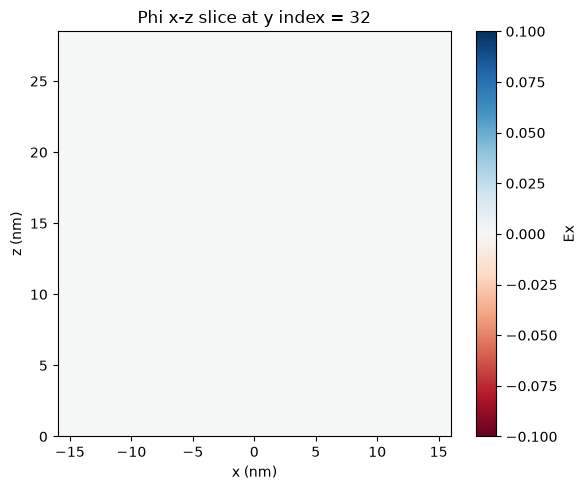

yt : [INFO     ] 2026-06-30 11:52:34,624 Parameters: current_time              = 2.5600000000000625e-10


yt : [INFO     ] 2026-06-30 11:52:34,624 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:34,625 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:34,625 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


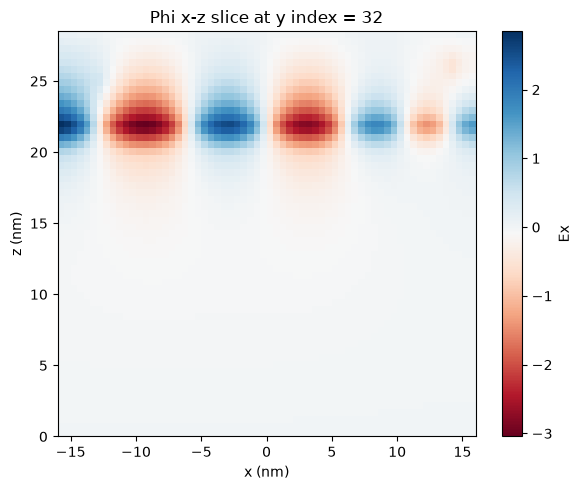

yt : [INFO     ] 2026-06-30 11:52:34,868 Parameters: current_time              = 2.92400000000008e-10


yt : [INFO     ] 2026-06-30 11:52:34,868 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:34,869 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:34,869 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


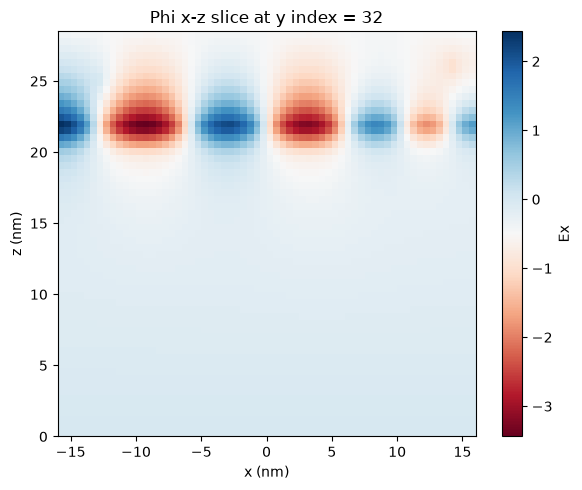

yt : [INFO     ] 2026-06-30 11:52:35,113 Parameters: current_time              = 3.2060000000000937e-10


yt : [INFO     ] 2026-06-30 11:52:35,113 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:35,114 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:35,114 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


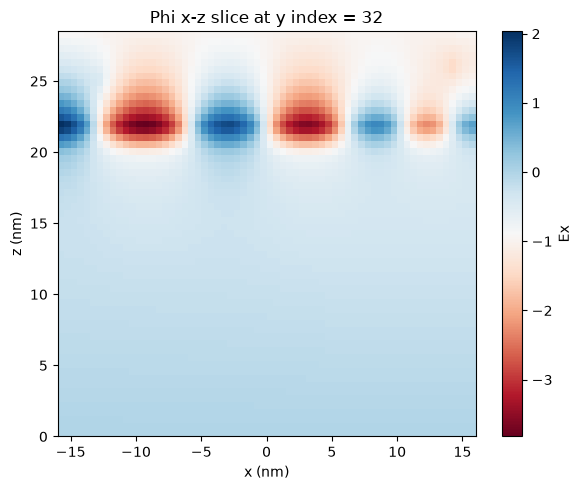

yt : [INFO     ] 2026-06-30 11:52:35,357 Parameters: current_time              = 3.626000000000114e-10


yt : [INFO     ] 2026-06-30 11:52:35,357 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:35,358 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:35,358 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


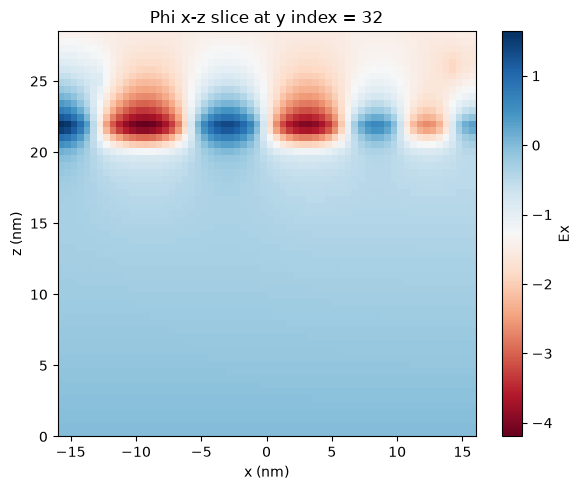

yt : [INFO     ] 2026-06-30 11:52:35,691 Parameters: current_time              = 5.034000000000084e-10


yt : [INFO     ] 2026-06-30 11:52:35,691 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:35,691 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:35,692 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


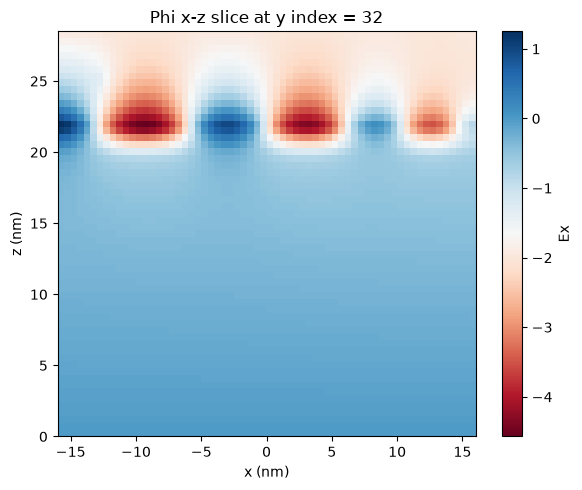

yt : [INFO     ] 2026-06-30 11:52:35,931 Parameters: current_time              = 8.507999999999354e-10


yt : [INFO     ] 2026-06-30 11:52:35,932 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:35,932 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:35,933 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


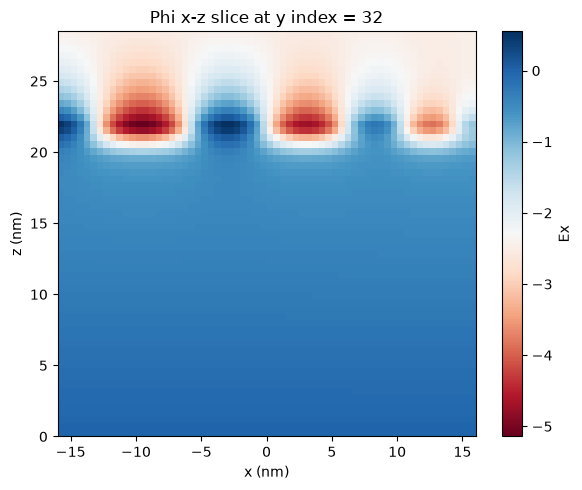

yt : [INFO     ] 2026-06-30 11:52:36,172 Parameters: current_time              = 8.597999999999335e-10


yt : [INFO     ] 2026-06-30 11:52:36,173 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:36,173 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:36,174 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


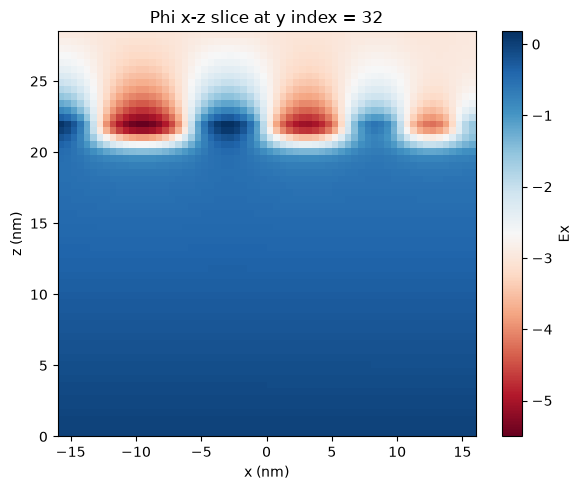

yt : [INFO     ] 2026-06-30 11:52:36,415 Parameters: current_time              = 8.689999999999315e-10


yt : [INFO     ] 2026-06-30 11:52:36,415 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:36,416 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:36,416 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


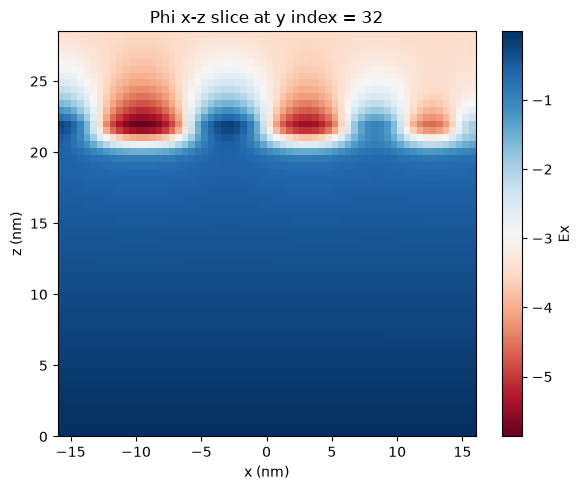

yt : [INFO     ] 2026-06-30 11:52:36,656 Parameters: current_time              = 8.787999999999295e-10


yt : [INFO     ] 2026-06-30 11:52:36,656 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:36,656 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:36,657 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


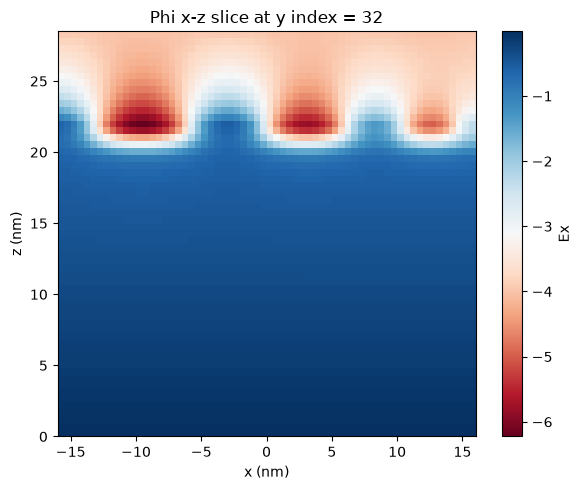

yt : [INFO     ] 2026-06-30 11:52:37,004 Parameters: current_time              = 8.889999999999273e-10


yt : [INFO     ] 2026-06-30 11:52:37,005 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:37,005 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:37,006 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


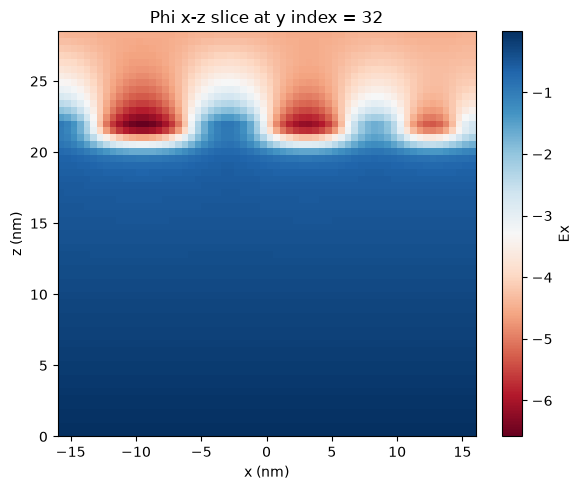

yt : [INFO     ] 2026-06-30 11:52:37,244 Parameters: current_time              = 8.987999999999253e-10


yt : [INFO     ] 2026-06-30 11:52:37,245 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:37,245 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:37,246 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


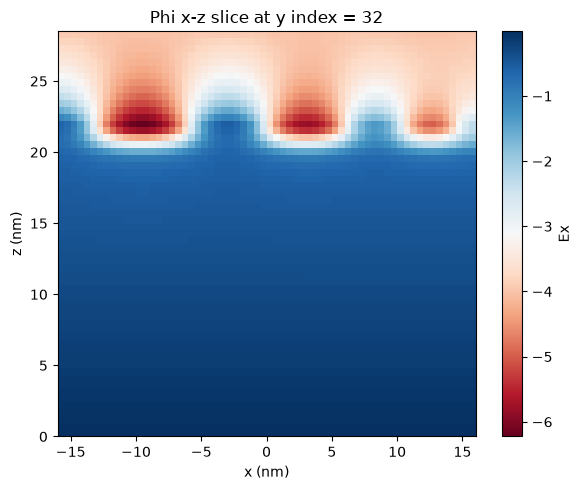

yt : [INFO     ] 2026-06-30 11:52:37,485 Parameters: current_time              = 9.081999999999233e-10


yt : [INFO     ] 2026-06-30 11:52:37,485 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:37,486 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:37,487 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


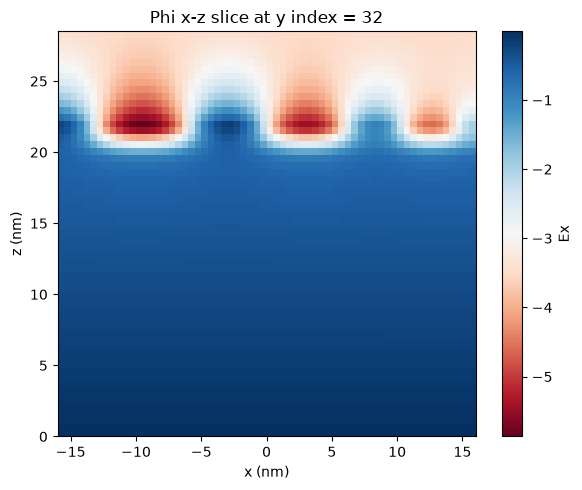

yt : [INFO     ] 2026-06-30 11:52:37,723 Parameters: current_time              = 9.171999999999214e-10


yt : [INFO     ] 2026-06-30 11:52:37,723 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:37,724 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:37,724 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


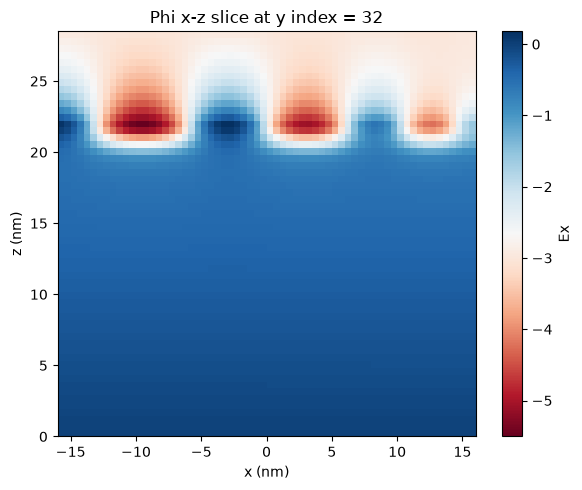

yt : [INFO     ] 2026-06-30 11:52:37,962 Parameters: current_time              = 9.259999999999196e-10


yt : [INFO     ] 2026-06-30 11:52:37,962 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:37,963 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:37,963 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


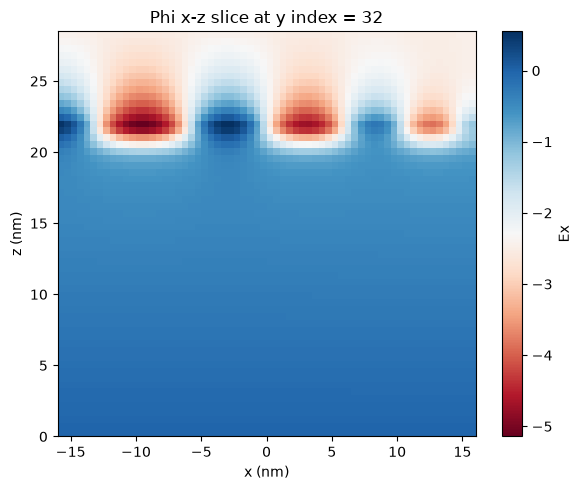

yt : [INFO     ] 2026-06-30 11:52:38,201 Parameters: current_time              = 9.343999999999193e-10


yt : [INFO     ] 2026-06-30 11:52:38,201 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:38,202 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:38,203 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


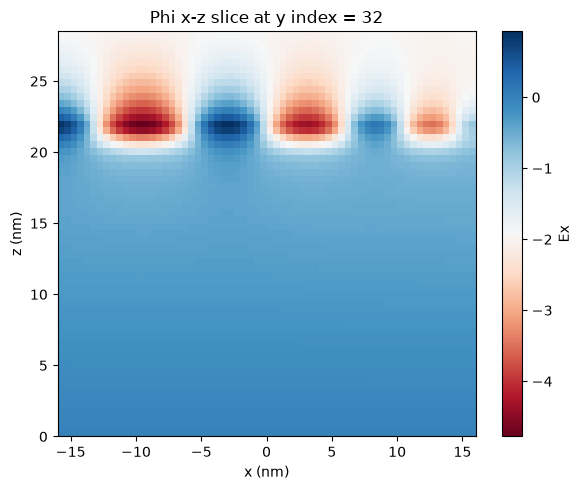

yt : [INFO     ] 2026-06-30 11:52:38,442 Parameters: current_time              = 9.42799999999922e-10


yt : [INFO     ] 2026-06-30 11:52:38,443 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:38,443 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:38,444 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


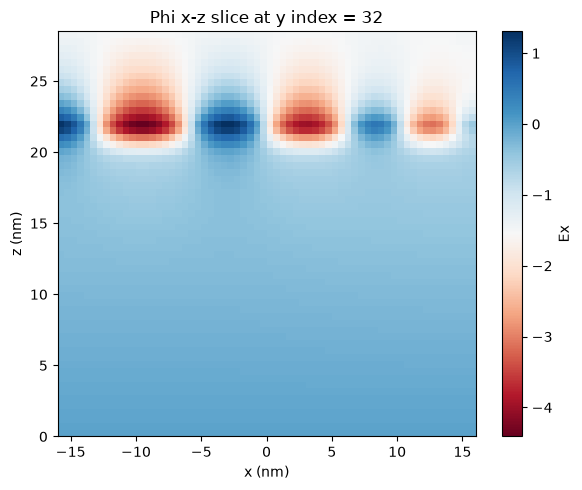

yt : [INFO     ] 2026-06-30 11:52:38,785 Parameters: current_time              = 9.509999999999244e-10


yt : [INFO     ] 2026-06-30 11:52:38,785 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:38,785 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:38,786 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


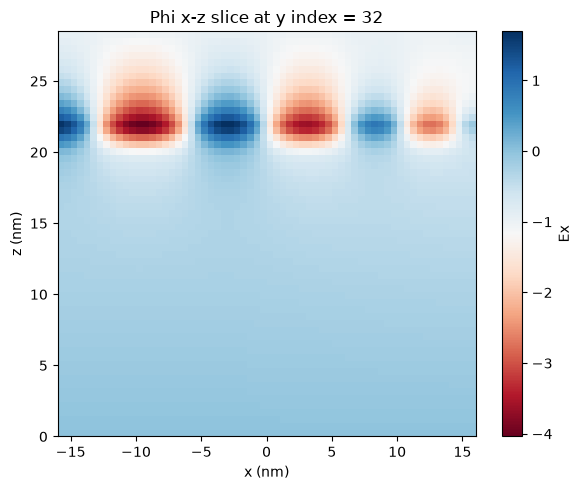

yt : [INFO     ] 2026-06-30 11:52:39,036 Parameters: current_time              = 9.59199999999927e-10


yt : [INFO     ] 2026-06-30 11:52:39,037 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:39,037 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:39,037 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


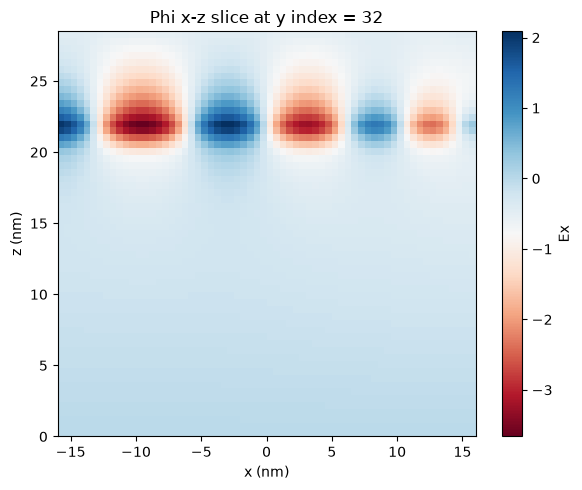

yt : [INFO     ] 2026-06-30 11:52:39,281 Parameters: current_time              = 9.671999999999294e-10


yt : [INFO     ] 2026-06-30 11:52:39,282 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:39,282 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:39,283 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


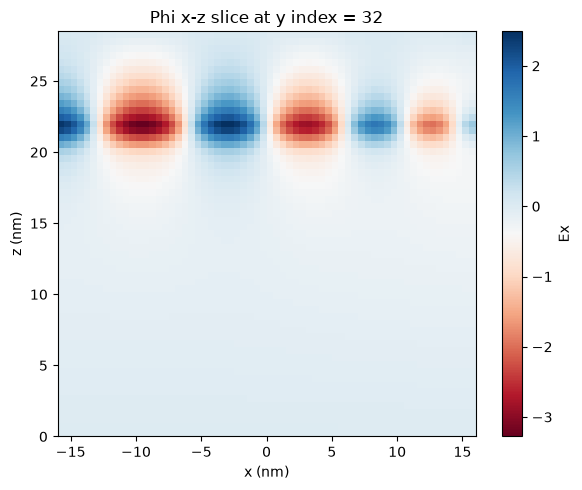

yt : [INFO     ] 2026-06-30 11:52:39,525 Parameters: current_time              = 9.751999999999319e-10


yt : [INFO     ] 2026-06-30 11:52:39,525 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:39,525 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:39,526 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


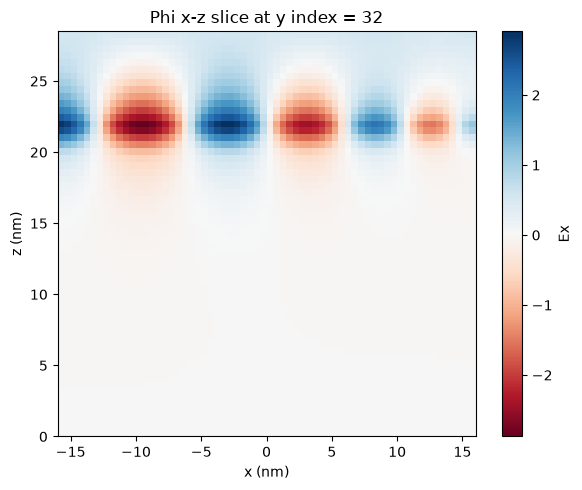

yt : [INFO     ] 2026-06-30 11:52:39,765 Parameters: current_time              = 9.831999999999343e-10


yt : [INFO     ] 2026-06-30 11:52:39,765 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:39,766 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:39,766 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


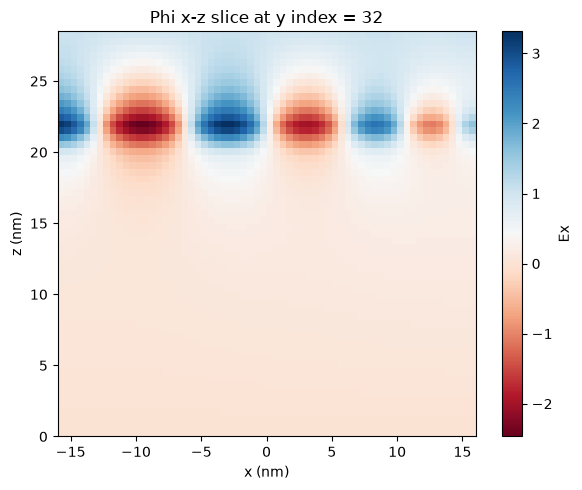

yt : [INFO     ] 2026-06-30 11:52:40,008 Parameters: current_time              = 9.913999999999368e-10


yt : [INFO     ] 2026-06-30 11:52:40,008 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:40,008 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:40,009 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


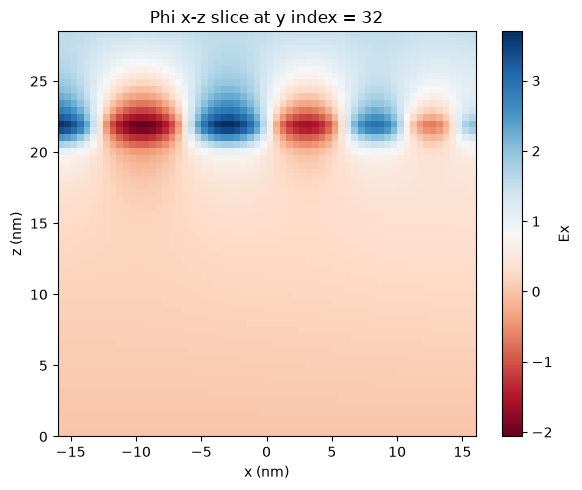

yt : [INFO     ] 2026-06-30 11:52:40,370 Parameters: current_time              = 9.997999999999394e-10


yt : [INFO     ] 2026-06-30 11:52:40,371 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:40,371 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:40,372 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


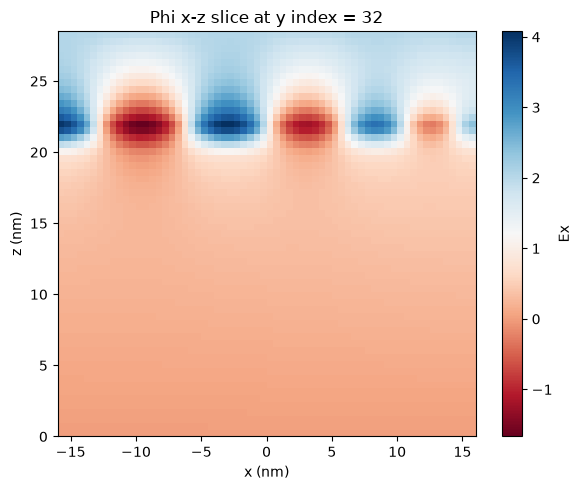

yt : [INFO     ] 2026-06-30 11:52:40,611 Parameters: current_time              = 1.0085999999999421e-09


yt : [INFO     ] 2026-06-30 11:52:40,611 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:40,611 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:40,612 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


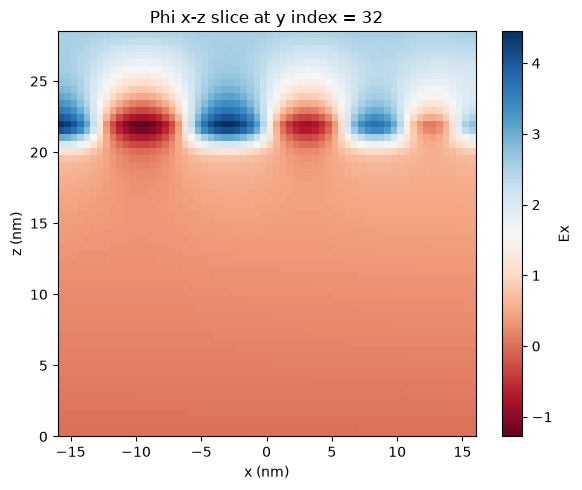

yt : [INFO     ] 2026-06-30 11:52:40,852 Parameters: current_time              = 1.0175999999999449e-09


yt : [INFO     ] 2026-06-30 11:52:40,852 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:40,852 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:40,853 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


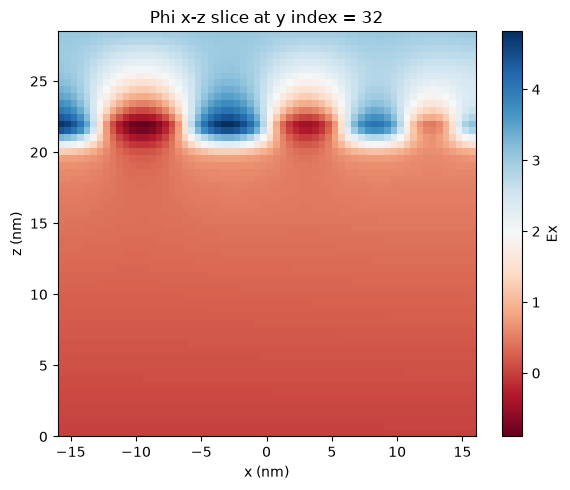

yt : [INFO     ] 2026-06-30 11:52:41,090 Parameters: current_time              = 1.0269999999999478e-09


yt : [INFO     ] 2026-06-30 11:52:41,091 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:41,092 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:41,092 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


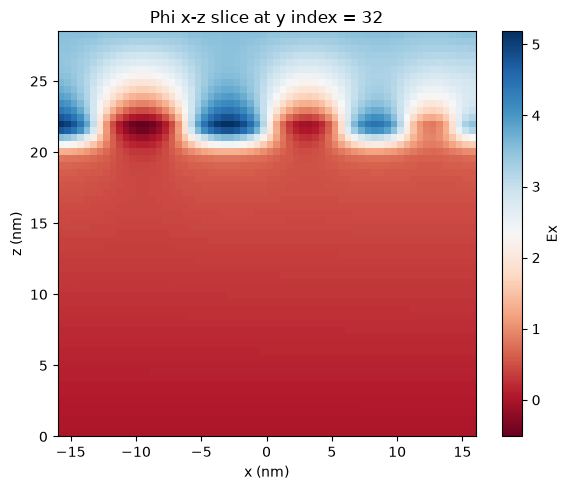

yt : [INFO     ] 2026-06-30 11:52:41,334 Parameters: current_time              = 1.0367999999999508e-09


yt : [INFO     ] 2026-06-30 11:52:41,335 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:41,336 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:41,337 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


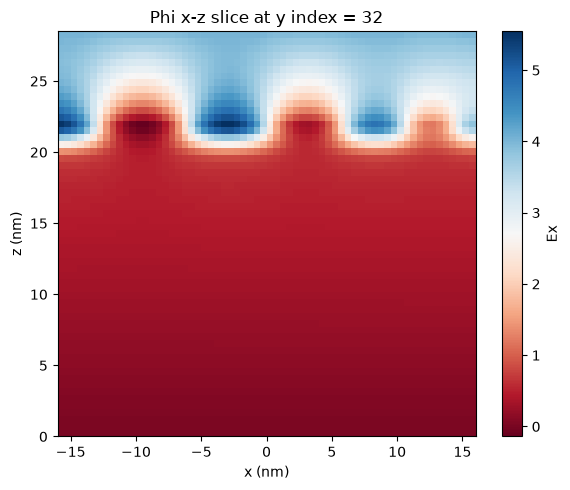

yt : [INFO     ] 2026-06-30 11:52:41,578 Parameters: current_time              = 1.047199999999954e-09


yt : [INFO     ] 2026-06-30 11:52:41,579 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:41,579 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:41,579 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


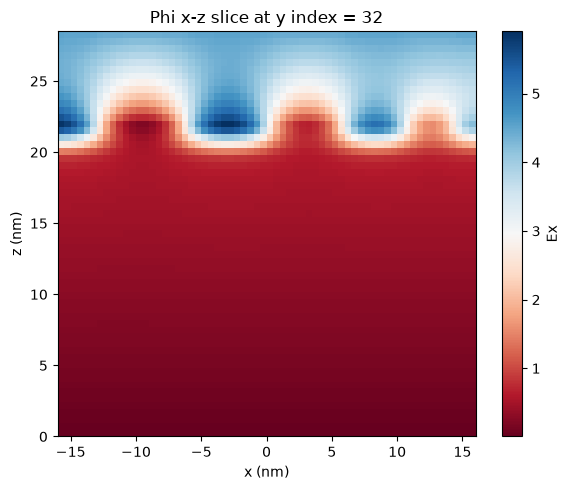

yt : [INFO     ] 2026-06-30 11:52:41,959 Parameters: current_time              = 1.057199999999957e-09


yt : [INFO     ] 2026-06-30 11:52:41,960 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:41,960 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:41,961 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


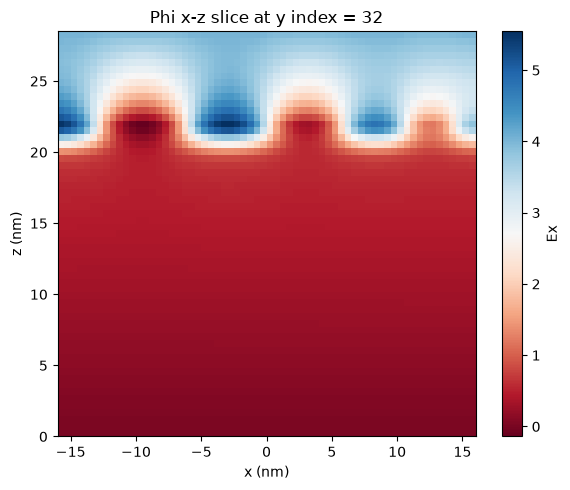

yt : [INFO     ] 2026-06-30 11:52:42,203 Parameters: current_time              = 1.06659999999996e-09


yt : [INFO     ] 2026-06-30 11:52:42,204 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:42,205 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:42,206 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


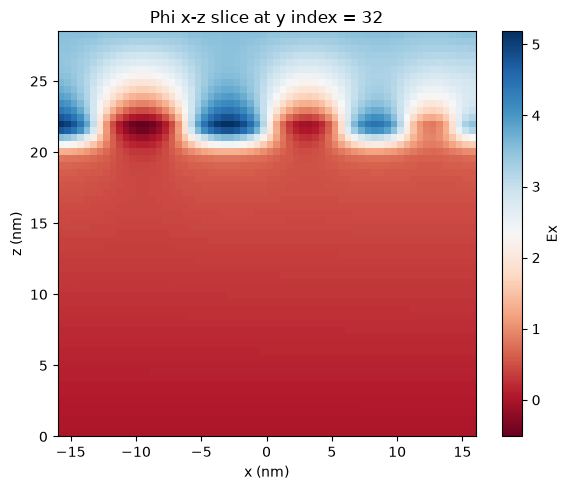

yt : [INFO     ] 2026-06-30 11:52:42,448 Parameters: current_time              = 1.0755999999999627e-09


yt : [INFO     ] 2026-06-30 11:52:42,449 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:42,450 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:42,451 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


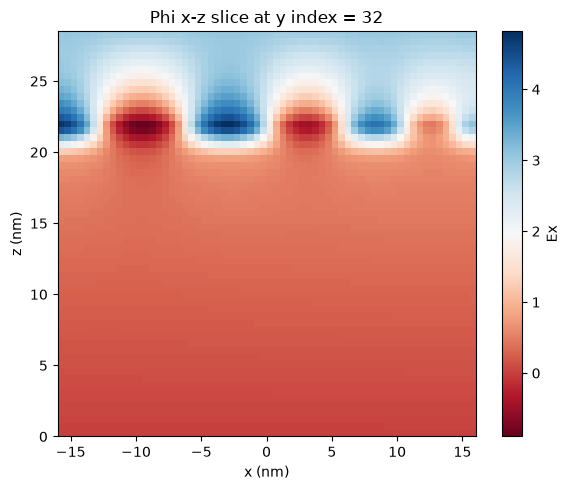

yt : [INFO     ] 2026-06-30 11:52:42,690 Parameters: current_time              = 1.0843999999999654e-09


yt : [INFO     ] 2026-06-30 11:52:42,691 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:42,692 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:42,693 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


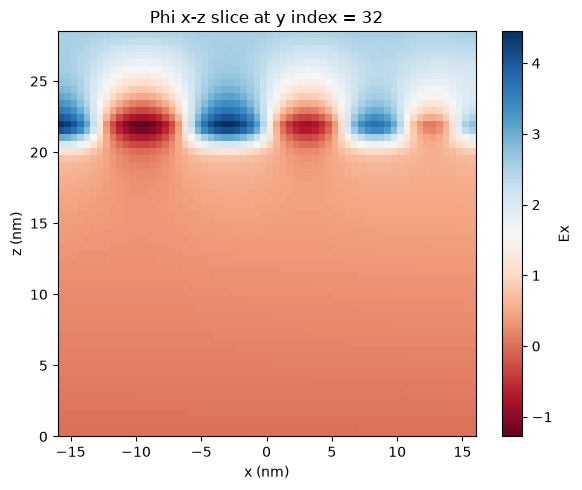

yt : [INFO     ] 2026-06-30 11:52:42,937 Parameters: current_time              = 1.092999999999968e-09


yt : [INFO     ] 2026-06-30 11:52:42,938 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:42,939 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:42,940 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


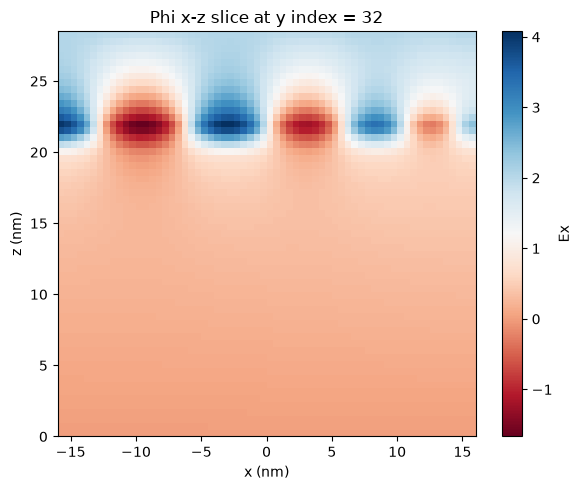

yt : [INFO     ] 2026-06-30 11:52:43,182 Parameters: current_time              = 1.1013999999999706e-09


yt : [INFO     ] 2026-06-30 11:52:43,184 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:43,185 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:43,186 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


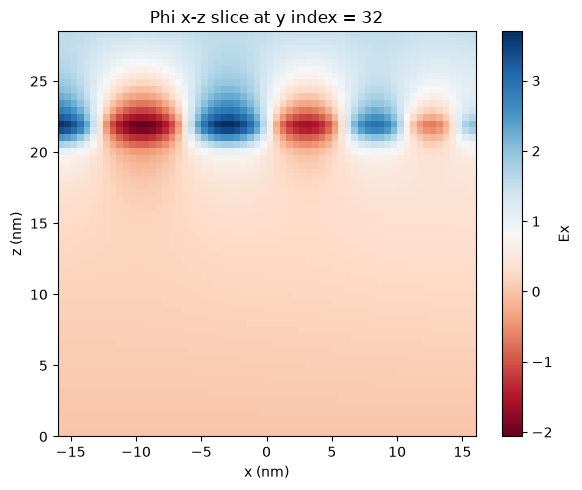

yt : [INFO     ] 2026-06-30 11:52:43,545 Parameters: current_time              = 1.109599999999973e-09


yt : [INFO     ] 2026-06-30 11:52:43,546 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:43,547 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:43,548 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


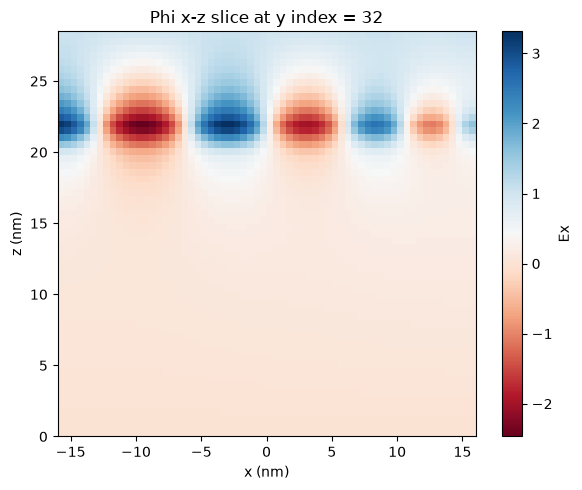

yt : [INFO     ] 2026-06-30 11:52:43,791 Parameters: current_time              = 1.1175999999999755e-09


yt : [INFO     ] 2026-06-30 11:52:43,792 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:43,793 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:43,794 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


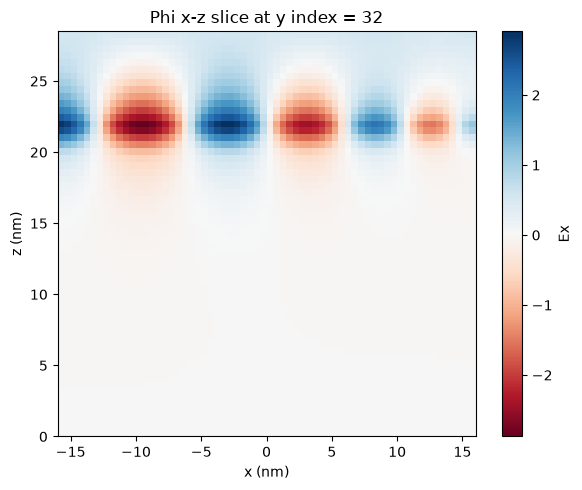

yt : [INFO     ] 2026-06-30 11:52:44,033 Parameters: current_time              = 1.125599999999978e-09


yt : [INFO     ] 2026-06-30 11:52:44,034 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:44,035 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:44,037 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


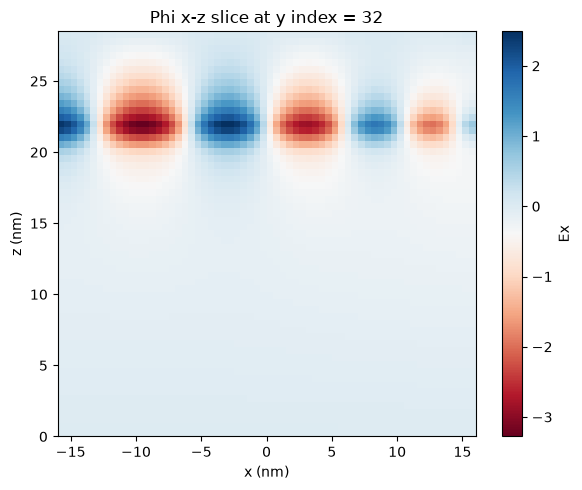

yt : [INFO     ] 2026-06-30 11:52:44,278 Parameters: current_time              = 1.1335999999999805e-09


yt : [INFO     ] 2026-06-30 11:52:44,279 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:44,280 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:44,281 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


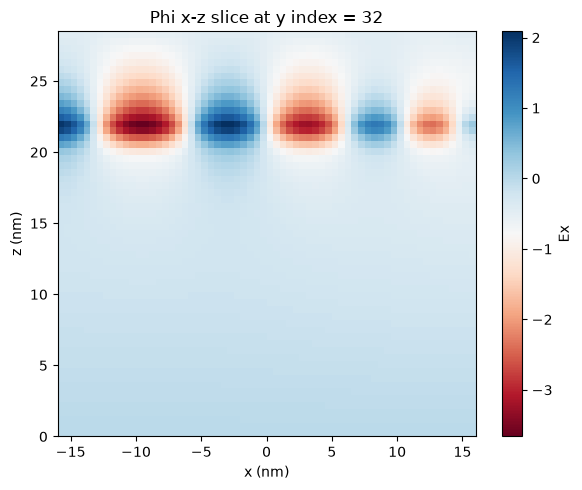

yt : [INFO     ] 2026-06-30 11:52:44,524 Parameters: current_time              = 1.141799999999983e-09


yt : [INFO     ] 2026-06-30 11:52:44,525 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:44,526 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:44,527 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


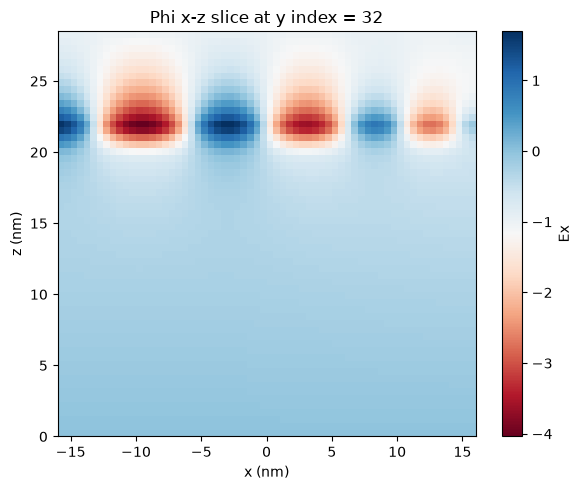

yt : [INFO     ] 2026-06-30 11:52:44,769 Parameters: current_time              = 1.1499999999999855e-09


yt : [INFO     ] 2026-06-30 11:52:44,770 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:44,771 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:44,772 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


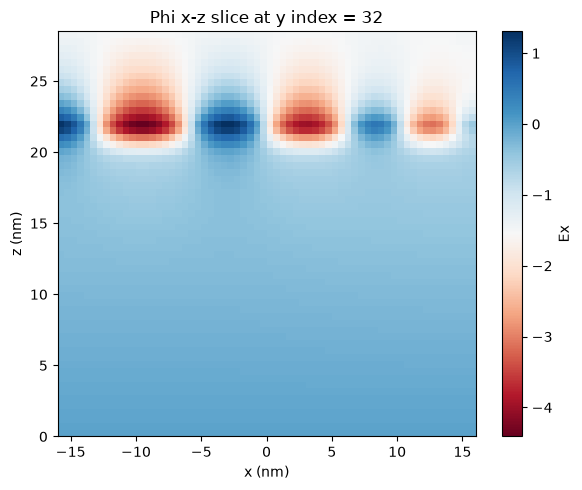

yt : [INFO     ] 2026-06-30 11:52:45,124 Parameters: current_time              = 1.158399999999988e-09


yt : [INFO     ] 2026-06-30 11:52:45,125 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:45,126 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:45,127 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


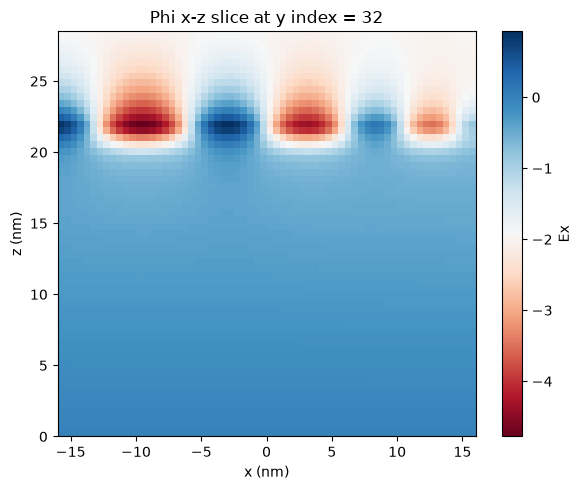

yt : [INFO     ] 2026-06-30 11:52:45,366 Parameters: current_time              = 1.1669999999999907e-09


yt : [INFO     ] 2026-06-30 11:52:45,367 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:45,368 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:45,370 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


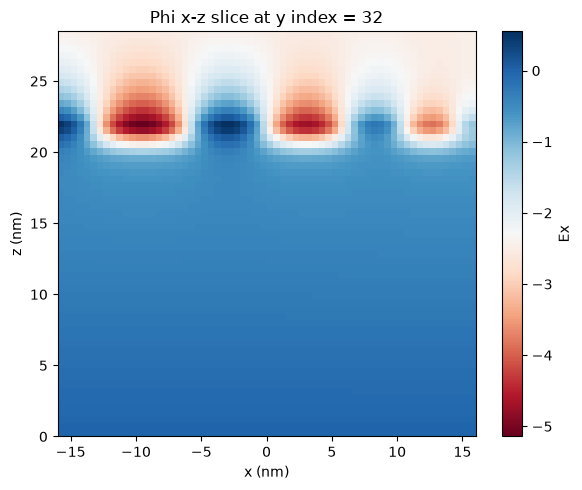

yt : [INFO     ] 2026-06-30 11:52:45,622 Parameters: current_time              = 1.1759999999999935e-09


yt : [INFO     ] 2026-06-30 11:52:45,622 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:45,623 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:45,623 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


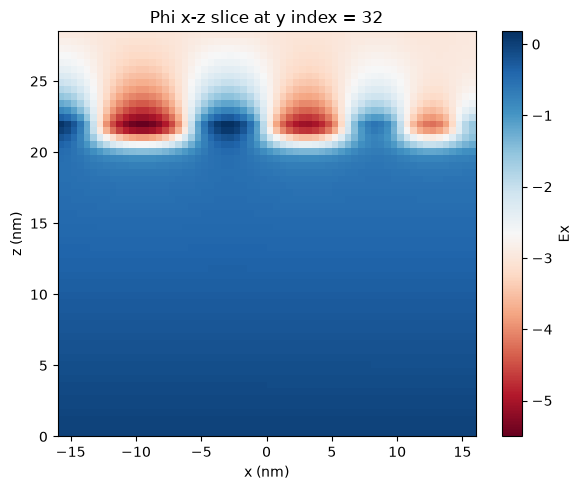

yt : [INFO     ] 2026-06-30 11:52:45,868 Parameters: current_time              = 1.1851999999999963e-09


yt : [INFO     ] 2026-06-30 11:52:45,869 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:45,870 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:45,871 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


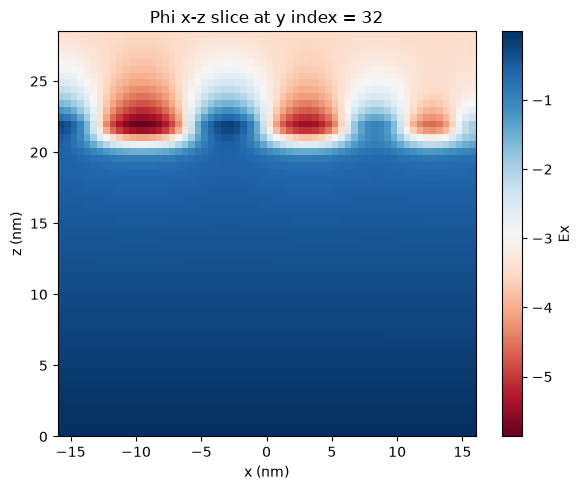

yt : [INFO     ] 2026-06-30 11:52:46,112 Parameters: current_time              = 1.1949999999999993e-09


yt : [INFO     ] 2026-06-30 11:52:46,113 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:46,114 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:46,115 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


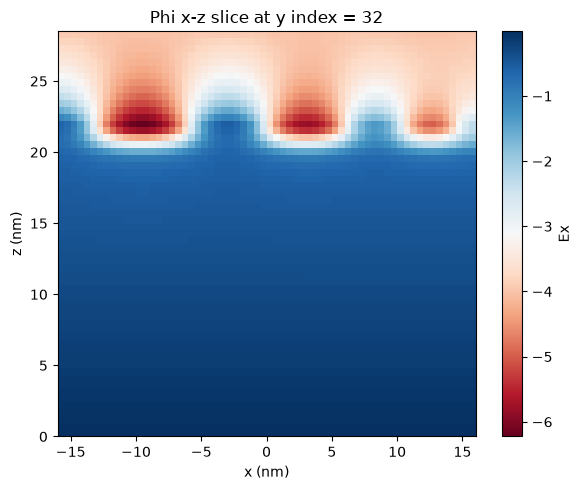

yt : [INFO     ] 2026-06-30 11:52:46,360 Parameters: current_time              = 1.2052000000000024e-09


yt : [INFO     ] 2026-06-30 11:52:46,361 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:46,362 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:46,364 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


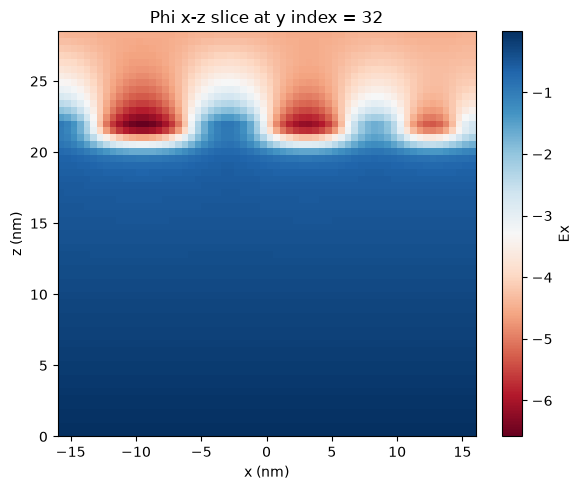

In [13]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-06-30 11:52:46,734 Parameters: current_time              = 2.92400000000008e-10


yt : [INFO     ] 2026-06-30 11:52:46,735 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:46,736 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:46,737 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


E_array shape = (64, 64, 59)


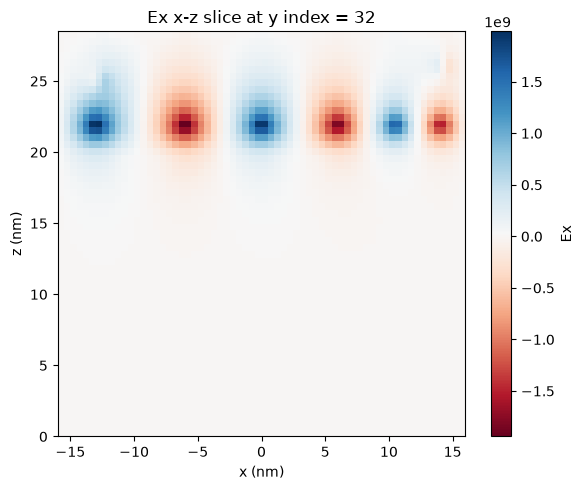

In [14]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[2] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

yt : [INFO     ] 2026-06-30 11:52:47,016 Parameters: current_time              = 8.889999999999273e-10


Plotfiles to draw:
  plt00004445
  plt00004494
  plt00004541
  plt00004586
  plt00004630
  plt00004672
  plt00004714
  plt00004755
  plt00004796
  plt00004836
  plt00004876
  plt00004916
  plt00004957
  plt00004999
  plt00005043
  plt00005088
  plt00005135
  plt00005184
  plt00005236
  plt00005286
  plt00005333
  plt00005378
  plt00005422
  plt00005465
  plt00005507
  plt00005548
  plt00005588
  plt00005628
  plt00005668
  plt00005709
  plt00005750
  plt00005792
  plt00005835
  plt00005880
  plt00005926
  plt00005975
  plt00006026
37 number of plotfiles will be drawn after filtering.


yt : [INFO     ] 2026-06-30 11:52:47,017 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:47,018 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:47,019 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


...

yt : [INFO     ] 2026-06-30 11:52:51,567 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:51,568 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:51,569 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Drawing 37 plots after filtering.


Saved figure: ./figs/Pz_FE_layer_stack.png


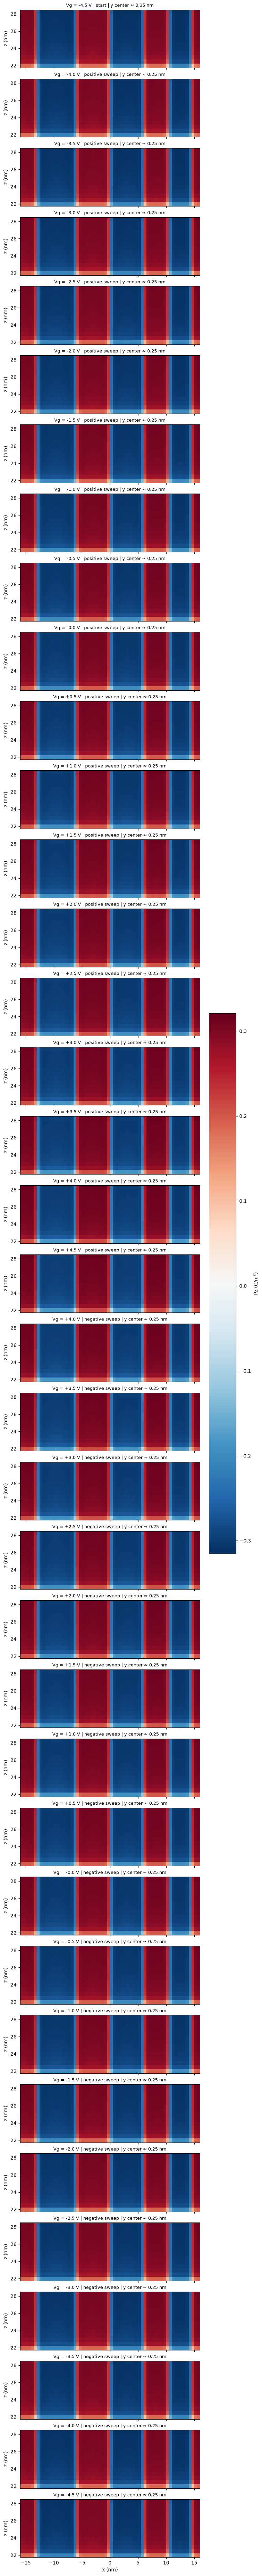

In [15]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# ==========================
# Selection list (NEW)
# ==========================
# format: (voltage, direction)
# voltage 用 None 表示 wildcard
# direction 用 None 表示 wildcard
'''
SELECT_LIST = [
    
    (-0.5, "positive sweep"), 
    (-0.5, "negative sweep"),
   
]
'''
SELECT_LIST = None  # 不過濾，全部畫出來
USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = False

# 輸出圖片名稱
SAVE_FIG = True
OUT_FIG = "./figs/Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid
    P*=-1
    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info



def match(rec, direction):# FILTER BY SELECT_LIST
    if not SELECT_LIST:
        return True
    V = rec["Vtop_mean"]

    for v_target, d_target in SELECT_LIST:

        ok_v = (v_target is None) or (
            np.isfinite(V) and np.isclose(V, v_target, atol=1e-1)
        )

        ok_d = (d_target is None) or (direction == d_target)

        if ok_v and ok_d:
            return True

    return False

# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

#忽略第一段
plot_names_use = plot_names_use[9:]
    
print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)
print(len(plot_names_use), "number of plotfiles will be drawn after filtering.")

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

filtered_records = []
filtered_directions = []

for rec, d in zip(records, directions):
    if match(rec, d):
        filtered_records.append(rec)
        filtered_directions.append(d)

records = filtered_records
directions = filtered_directions

# figure size
n = len(records)
print(f"Drawing {n} plots after filtering.")
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)


if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.1f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")
axes[-1].tick_params(axis='x', labelbottom=True)
'''
for ax in axes:
    ax.set_xlabel("x (nm)")
    ax.tick_params(axis='x', labelbottom=True)
'''
cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## PV

### User Settings

In [16]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = "./figs/MFIS_PV_curve.csv"
OUT_FIG = "./figs/MFIS_PV_curve.png"


### Utils

In [17]:
# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }



### Data Preparation

In [18]:



# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]
plot_names_use = plot_names_use[9:]  # skip first 9 plotfiles
rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-06-30 11:52:59,123 Parameters: current_time              = 8.889999999999273e-10


yt : [INFO     ] 2026-06-30 11:52:59,124 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:52:59,125 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:52:59,125 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


yt : [INFO     ] 2026-06-30 11:52:59,245 Parameters: current_time              = 8.987999999999253e-10


...

yt : [INFO     ] 2026-06-30 11:53:03,533 Parameters: current_time              = 1.2052000000000024e-09


yt : [INFO     ] 2026-06-30 11:53:03,534 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-30 11:53:03,535 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-30 11:53:03,536 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Read Pz with shape (64, 64, 59) from plts/plt00005975
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00005975 | step=5975 | Vg=-3.9685 V | <Pz>_FE=+2.360179e-02
Read Pz with shape (64, 64, 59) from plts/plt00006026
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00006026 | step=6026 | Vg=-4.4639 V | <Pz>_FE=+2.461874e-02
Saved CSV: ./figs/MFIS_PV_curve.csv


### plot pv

In [19]:
print(len(P))

37


Saved figure: ./figs/MFIS_PV_curve.png


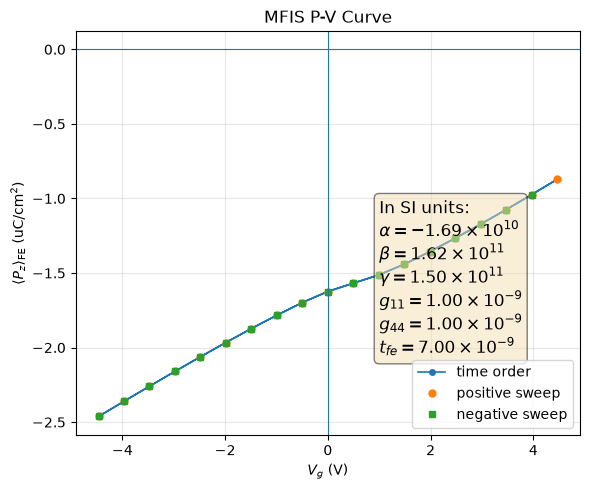

In [20]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(1, -1, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, -P*100, "-o", markersize=4, linewidth=1.2, label="time order")
# paper data
#plt.plot(Vp, Pp, "-o", markersize=4, linewidth=1.2, label="paper")
# no f data
#plt.plot(Vnf, -Pnf*100, "-o", markersize=4, linewidth=1.2, label="before")
# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], -P[pos]*100, "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], -P[neg]*100, "s", markersize=5, label="negative sweep")


plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (uC/cm$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()

# update html

## utils

In [21]:
from pathlib import Path
from datetime import datetime
import re


def make_image_cell(img_path):
    if img_path is None or img_path == "":
        return "<td>No Image</td>"

    return f"""
<td>
<a href="{img_path}" target="_blank">
<img src="{img_path}">
</a>
</td>
"""


def update_dashboard(
    folder,
    params,
    tfe,
    start_time=None,
    end_time=None,
    elapsed_time=None,
    pv=None,
    pz=None,
    html_file="index.html",
):
    """
    folder : 資料夾名稱 (例如 MFIS001)

    params : dict
        {
            "alpha":...,
            "beta":...,
            ...
        }

    tfe : float

    pv,pz : 相對於 index.html 的圖片路徑
    """

    html_file = Path(html_file)

    with open(html_file, encoding="utf8") as f:
        html = f.read()

    # ---------- 防止重複 ----------
    
    folders = set(
        re.findall(
            r'<tr>\s*<td[^>]*>(.*?)</td>',
            html,
            re.DOTALL
        )
    )

    if folder in folders:
        print(f"{folder} already exists. Skip.")
        return

    # ---------- 更新時間 ----------
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    html = re.sub(
        r'(<span id="last_update">).*?(</span>)',
        rf"\g<1>{now}\g<2>",
        html,
        flags=re.S,
    )

    # ---------- 更新總數 ----------
    # 網頁java自動更新總數，這裡不需要

    
    # ---------- 新增一列 ----------
    row = f'<tr>\n<td>{folder}</td>'

    wanted = [
        "alpha",
        "beta",
        "gamma",
        "BigGamma",
        "g11",
        "g44",
        "FE_lo",
        "FE_hi",
    ]

    for p in wanted:
        if p == "FE_lo" or p == "FE_hi":
            continue
            
        value = params.get(p)

        if value is None:
            txt = ""

        elif isinstance(value, list):
            txt = " ".join(f"{v:.3e}" for v in value)

        else:
            txt = f"{value:.3e}"

        row += f'<td>{txt}</td>'

    row += f'<td>{tfe:.3e}</td>'
    row += f'<td>{start_time}</td>'
    row += f'<td>{end_time}</td>'
    row += f'<td>{elapsed_time}</td>'
    
    

    row += make_image_cell(pv)

    row += make_image_cell(pz)

    row += "\n</tr>\n"
    
    html = html.replace(
        "</tbody>",
        row + "</tbody>",
    )

    with open(html_file, "w", encoding="utf8") as f:
        f.write(html)

    print(f"{folder} added.")

## main

In [22]:
from pathlib import Path

folder = Path.cwd().name
cwd = Path.cwd()

root = cwd.parent

pv = (cwd / "figs" / "MFIS_PV_curve.png").relative_to(root).as_posix()

pz = (cwd / "figs" / "Pz_FE_layer_stack.png").relative_to(root).as_posix()

update_dashboard(
    folder=folder,
    params=params,
    tfe=T_FE,
    start_time=start_time,
    end_time=end_time,
    elapsed_time=elapsed_hms,
    pv=pv,
    pz=pz,
    html_file=root / "index.html",
)




MFIS_t_7_nomi_12 added.
